# HBI&nbsp;02 — the forward-response kernel (the deconvolution engine)

**Where we are.** NB0 set up the estimand (a population $f(N,z)$ measured from a
*catalog* of imperfect detections). NB1 showed the whole machine close on a
*synthetic* catalog: inject a known $f(N)$, forward-simulate detections, run the
real MAP deconvolution, recover the truth. The one thing NB1 hand-built was the
**forward kernel** — the object that maps true columns $N$ to measured columns
$\hat x$. This notebook opens up the *real* kernel, measured on the 2LPT-0 mock.

**What the kernel is.** Every DLA the GP reports carries a measured
$\hat x=\log_{10}\hat N_{\rm HI}$ that differs from the absorber's true $N$ by a
noisy, *biased* amount. The kernel is the conditional density of that error:

$$ p(\hat x \mid N,\,\mathrm{SNR},\,z) $$

— the **forward response**. It is what the estimator *deconvolves*: given the
catalog of $\hat x_i$, undo the smear+bias to recover the true $f(N)$.

**Why this is the crux.** There are two superficially similar objects, and using
the wrong one silently double-counts the population:

| object | reads as | normalised over | role |
|---|---|---|---|
| **forward** $p(\hat x\mid N)$ | "given the truth $N$, where does $\hat x$ land" | $\hat x$ (so $\int p\,d\hat x=1$) | the **likelihood** — what we deconvolve |
| **GP posterior** $\kappa(N\mid\hat x)$ | "given the measurement $\hat x$, where was $N$" | $N$ (so $\sum_N \kappa=1$) | a *per-spectrum* belief, already prior-folded |

This notebook builds the real forward kernel from committed mock fixtures, draws
its centering / width / response matrix, and demonstrates the normalisation
discriminant numerically — the single fact that tells the two objects apart.

> **Mock only (2LPT-0).** No real-survey (LOA) values appear here. Every printed
> number is computed by the code in the cell — nothing is typed in.

> Companion notebooks: **NB0** motivation & estimand · **NB1** synthetic
> closure · **NB3** likelihood + MAP solve + MC band *using this kernel*.

In [1]:
%matplotlib inline
# --- ENV: pin BLAS to 1 thread BEFORE numpy is imported ----------------------
# Keeps polynomial-surface evaluation and the density interpolation bit-for-bit
# reproducible across machines (matches the production harness).
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS"):
    os.environ[_v] = "1"

# --- resolve repo root so the import works no matter the launch dir ----------
import sys
from pathlib import Path
_here = Path.cwd()
_root = next((p for p in (_here, *_here.parents)
              if (p / "CDDF_analysis" / "hbi" / "znz_kernel.py").exists()),
             None)
assert _root is not None, "could not locate repo root (CDDF_analysis/hbi/...)"
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import numpy as np
import matplotlib.pyplot as plt
# inline backend so the kernel figure embeds as a PNG in the notebook output.

# numpy 2.x renamed trapz -> trapezoid (this env is numpy 2.x).
_trapz = getattr(np, "trapezoid", getattr(np, "trapz", None))

# THE production forward-response dataclasses — the same code the estimator uses.
from CDDF_analysis.hbi.znz_kernel import ZNZModel, EmpiricalForwardDensity

# the committed mock fixtures (2LPT-0); resolved relative to the repo root.
TD = _root / "CDDF_analysis" / "hbi" / "tutorial_data"
print("repo root :", _root)
print("fixtures  :", TD)
assert (TD / "znz_2lpt0.npz").exists()
assert (TD / "forward_response_2lpt0.npz").exists()

repo root : /tmp/claude-114399728/-home-mfho-desi-gpy-dla-detection/61bff2ab-596e-490e-9db3-2dbe8f55d4d9/scratchpad/hbi_readme_wt
fixtures  : /tmp/claude-114399728/-home-mfho-desi-gpy-dla-detection/61bff2ab-596e-490e-9db3-2dbe8f55d4d9/scratchpad/hbi_readme_wt/CDDF_analysis/hbi/tutorial_data


## The crux: deconvolve the *forward* response, not the GP *posterior*

The likelihood the estimator needs answers a forward question — *given a true
column $N$ at this SNR and redshift, where does the GP's reported $\hat x$ land?*
That density,

$$ p(\hat x \mid N,\,\mathrm{SNR},\,z), \qquad \int p(\hat x\mid N)\,d\hat x = 1, $$

is normalised **over $\hat x$** at fixed $N$. Crucially $\sum_N p(\hat x\mid N)\neq1$
— the forward map does *not* sum to one across true columns.

The GP, by contrast, hands you a **posterior** for each spectrum:

$$ \kappa(N \mid \hat x), \qquad \sum_N \kappa(N\mid\hat x) = 1, $$

normalised **over $N$** at fixed $\hat x$. By Bayes these are related through the
population prior, $\kappa(N\mid\hat x)\propto p(\hat x\mid N)\,f(N)$ — but they are
**not interchangeable**. Contracting the catalog with $\kappa$ instead of $p$ is a
*category error*: $\kappa$ already has the population folded in (through $f(N)$),
so summing it over the catalog double-counts the population you are trying to
measure. The forward map $p$ is prior-free in $N$; that is exactly why it can be
deconvolved.

**The "Bayes flip" — why the posterior *looks* fine but cannot deconvolve.**
Near the prior edge at $\log N_{\rm HI}\approx 20.3$ the forward response is
strongly **up-migrating**: a true sub-DLA scatters *up* into the DLA range more
often than a true DLA scatters down (Eddington bias against a steep $f(N)$). So
$p(\hat x\mid N)$ has a real, $\hat x$-rising conditional bias. Yet the GP
*posterior* $\kappa(N\mid\hat x)$ shows almost **no** conditional shift — because
the up-migrating forward smear is **balanced** by the steep falling $f(N)$ prior
that multiplies it. The two effects cancel in the posterior. That cancellation
is comforting if you only look at $\kappa$ (it "looks unbiased"), but it is
precisely why $\kappa$ **cannot** remove the over-recovery: the bias is hidden
inside the prior it carries. Only the *forward* response, which keeps the
up-migration explicit and prior-free, can be inverted to re-steepen the high-$N$
tail and fix $\Omega_{\rm HI}$.

## Load the real 2LPT-0 forward kernel

Two committed fixtures reconstruct the production dataclasses:

* `znz_2lpt0.npz` → **`ZNZModel`**: the fitted *parametric* forward surfaces —
  the conditional bias $b(\hat x,z)=\langle\hat x-x_{\rm true}\rangle$ and the
  conditional scatter $\sigma(\hat x,z)$ (both 2-D polynomials, centred at a
  reference point for numerical stability).
* `forward_response_2lpt0.npz` → **`EmpiricalForwardDensity`**: the genuine
  *non-parametric* forward density $p(\hat x\mid N,\mathrm{SNR},z)$ — a smoothed
  truth-match residual histogram per $(\mathrm{SNR},z)$ cell, evaluated at several
  true-$N$ anchors. This is the headline `resp_family="empirical"` kernel.

Both are pure mock products (no real-survey input).

In [2]:
# --- ZNZModel: parametric bias / scatter surfaces ----------------------------
z = np.load(TD / "znz_2lpt0.npz", allow_pickle=True)
znz = ZNZModel(
    b_coef=z["b_coef"], sig_coef=z["sig_coef"],
    xhat_ref=float(z["xhat_ref"]), z_ref=float(z["z_ref"]),
    b_ref=float(z["b_ref"]), sig_ref=float(z["sig_ref"]),
    z_covariate=str(z["z_covariate"]),
    deg_xhat=int(z["deg_xhat"]), deg_z=int(z["deg_z"]),
)

# --- EmpiricalForwardDensity: non-parametric p(x̂|N,SNR,z) -------------------
f = np.load(TD / "forward_response_2lpt0.npz", allow_pickle=True)
emp = EmpiricalForwardDensity(
    rho=f["emp_rho"], N_anchors=f["emp_N_anchors"], r_grid=f["emp_r_grid"],
    snr_edges=f["emp_snr_edges"], z_edges=f["emp_z_edges"],
)

print("ZNZModel (parametric forward surfaces)")
print(f"  reference point      : x̂_ref={znz.xhat_ref:.3f}, z_ref={znz.z_ref:.3f}")
print(f"  b_ref (bias @ ref)   : {znz.b_ref:+.4f} dex   (already > 0: up-migration)")
print(f"  sigma_ref (@ ref)    : {znz.sig_ref:.4f} dex")
print(f"  poly degrees (x̂, z)  : ({znz.deg_xhat}, {znz.deg_z})")
print()
print("EmpiricalForwardDensity (non-parametric p(x̂|N,SNR,z))")
print(f"  rho grid shape       : {emp.rho.shape}  (n_snr, n_z, n_anchor, n_r)")
print(f"  SNR cell edges       : {emp.snr_edges}")
print(f"  z   cell edges       : {emp.z_edges}")
print(f"  residual grid r=x̂-N  : [{emp.r_grid[0]:+.2f}, {emp.r_grid[-1]:+.2f}] "
      f"dex, {len(emp.r_grid)} pts")
print(f"  N_true anchors [0,0] : {np.round(emp.N_anchors[0,0], 3)}")

ZNZModel (parametric forward surfaces)
  reference point      : x̂_ref=20.055, z_ref=2.480
  b_ref (bias @ ref)   : +0.0855 dex   (already > 0: up-migration)
  sigma_ref (@ ref)    : 0.1435 dex
  poly degrees (x̂, z)  : (1, 2)

EmpiricalForwardDensity (non-parametric p(x̂|N,SNR,z))
  rho grid shape       : (3, 3, 7, 121)  (n_snr, n_z, n_anchor, n_r)
  SNR cell edges       : [2.  3.5 6.5 inf]
  z   cell edges       : [0.   2.56 2.96  inf]
  residual grid r=x̂-N  : [-1.50, +1.50] dex, 121 pts
  N_true anchors [0,0] : [19.503 19.875 20.093 20.297 20.511 20.767 21.216]


## The kernel figure

Four panels, adapted from the canonical generator `scripts/plot_kernel.py`:

* **(a) forward centering** $E[\hat x\mid N_{\rm true}]$ vs $N_{\rm true}$, with
  the identity line. It sits **above** identity → **up-migration**.
* **(b) bias surface** $b(\hat x,z)=\langle\hat x-x_{\rm true}\rangle$ — rising
  with $\hat x$ (closer to the prior edge → more up-migration) at three $z$ slices.
* **(c) forward width** $\sigma(\hat x,z)$ — shrinking from $\sim0.15$ dex at the
  sub-DLA/LLS end to $\sim0.10$ dex at high $N$.
* **(d) forward response matrix** $p(\hat x\mid N_{\rm true})$, column-normalised
  over $\hat x$ at fixed $N$ — the object the HBI A-build deconvolves; the cyan
  curve is the panel-(a) centering re-drawn on the matrix.

The centering / matrix are a population-representative equal-weight average of
the empirical density over all populated $(\mathrm{SNR},z)$ cells, each evaluated
at its cell centre — exactly the construction in `plot_kernel.main`.

SELF-CHECK PASS: mean forward up-migration over DLA range (N>=20.3) b = +0.0458 dex  > 0
  E[x̂|N]-N range: +0.0172 .. +0.2509 dex


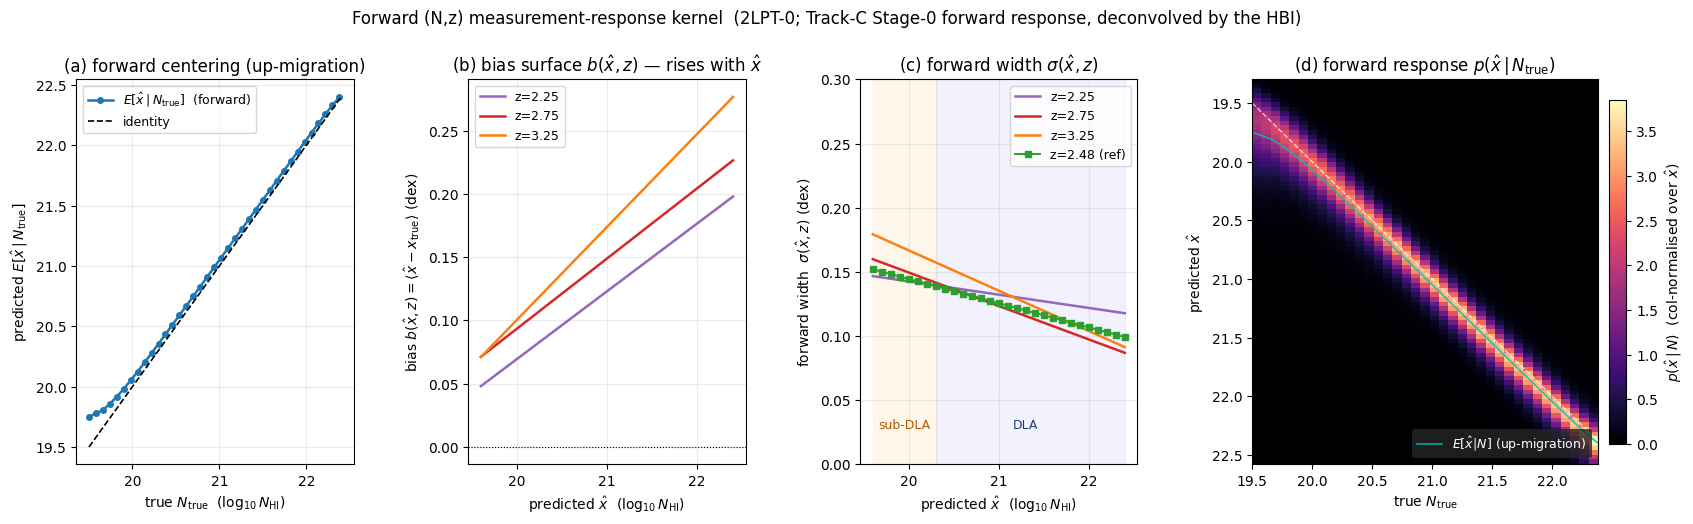

In [3]:
# ---- (a)/(b) parametric forward surfaces b(x̂,z), sigma(x̂,z) ---------------
z_ref = float(znz.z_ref)
z_slices = [2.25, 2.75, 3.25]
cols = ["#9467bd", "#d62728", "#ff7f0e"]
xs = np.arange(19.6, 22.4 + 1e-9, 0.1)
sig_ref_curve = znz.sigma(xs, np.full_like(xs, z_ref))

# ---- (c)/(d) population-representative forward response matrix p(x̂|N) -------
# Equal-weight average of the empirical density over all populated (SNR,z) cells,
# each evaluated at the cell-centre (SNR, z)  [verbatim logic of plot_kernel.main].
Ntrue = np.arange(19.5, 22.4 + 1e-9, 0.08)
xhat  = np.arange(19.3, 22.6 + 1e-9, 0.04)
snr_edges, z_edges = emp.snr_edges, emp.z_edges
snr_cen = []
for a in range(len(snr_edges) - 1):
    lo, hi = snr_edges[a], snr_edges[a + 1]
    snr_cen.append(0.5 * (lo + hi) if np.isfinite(hi) else lo * 1.5)
z_cen = []
for a in range(len(z_edges) - 1):
    lo, hi = z_edges[a], z_edges[a + 1]
    z_cen.append(0.5 * (lo + hi) if np.isfinite(hi) and lo > 0
                 else (2.2 if lo == 0 else lo * 1.05))

P = np.zeros((len(xhat), len(Ntrue)))
ncell = 0
for sc in snr_cen:
    for zc in z_cen:
        for j, Nt in enumerate(Ntrue):
            P[:, j] += emp.density(xhat, np.full_like(xhat, Nt), sc, zc)
        ncell += 1
P /= ncell

# column-normalise p(x̂|N) over x̂ at fixed N (the forward convention)
col = _trapz(P, xhat, axis=0)
Pn = P / np.where(col[None, :] > 1e-9, col[None, :], 1.0)
# forward centering E[x̂|N] (the object that rises ABOVE identity = up-migration)
Exhat = (Pn * xhat[:, None]).sum(0) / np.clip(Pn.sum(0), 1e-12, None)
up_migration = Exhat - Ntrue

# ---- SELF-CHECK: forward centering ABOVE identity over the DLA range --------
dla = Ntrue >= 20.3
mean_up_dla = float(up_migration[dla].mean())
assert mean_up_dla > 0.0, f"forward centering NOT above identity (b={mean_up_dla})"
print(f"SELF-CHECK PASS: mean forward up-migration over DLA range "
      f"(N>=20.3) b = {mean_up_dla:+.4f} dex  > 0")
print(f"  E[x̂|N]-N range: {up_migration.min():+.4f} .. {up_migration.max():+.4f} dex")

# ---- draw the four-panel figure --------------------------------------------
fig = plt.figure(figsize=(20, 5.0))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 1.35], wspace=0.38)

# (a) forward centering E[x̂|N] vs N
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(Ntrue, Exhat, "o-", color="#1f77b4", ms=4, lw=1.8,
         label=r"$E[\hat x\,|\,N_{\rm true}]$  (forward)")
ax0.plot([19.5, 22.4], [19.5, 22.4], "k--", lw=1.2, label="identity")
ax0.set_xlabel(r"true $N_{\rm true}$  ($\log_{10} N_{\rm HI}$)")
ax0.set_ylabel(r"predicted $E[\hat x\,|\,N_{\rm true}]$")
ax0.set_title("(a) forward centering (up-migration)")
ax0.legend(loc="upper left", fontsize=9)
ax0.grid(alpha=0.25)

# (b) bias surface b(x̂,z), rising with x̂
ax1 = fig.add_subplot(gs[0, 1])
for zc, cc in zip(z_slices, cols):
    ax1.plot(xs, znz.b(xs, np.full_like(xs, zc)), "-", color=cc, lw=1.8,
             label=f"z={zc:.2f}")
ax1.axhline(0, color="k", lw=0.8, ls=":")
ax1.set_xlabel(r"predicted $\hat x$  ($\log_{10} N_{\rm HI}$)")
ax1.set_ylabel(r"bias $b(\hat x,z)=\langle\hat x-x_{\rm true}\rangle$ (dex)")
ax1.set_title(r"(b) bias surface $b(\hat x,z)$ — rises with $\hat x$")
ax1.legend(fontsize=9, loc="upper left")
ax1.grid(alpha=0.25)

# (c) forward width sigma(x̂,z)
ax2 = fig.add_subplot(gs[0, 2])
for zc, cc in zip(z_slices, cols):
    ax2.plot(xs, znz.sigma(xs, np.full_like(xs, zc)), "-", color=cc, lw=1.8,
             label=f"z={zc:.2f}")
ax2.plot(xs, sig_ref_curve, "s-", color="#2ca02c", ms=4, lw=1.4,
         label=f"z={z_ref:.2f} (ref)")
ax2.axvspan(19.6, 20.3, color="orange", alpha=0.08)
ax2.axvspan(20.3, 22.4, color="blue", alpha=0.05)
ax2.text(19.95, 0.028, "sub-DLA", fontsize=9, ha="center", color="#b35900")
ax2.text(21.3, 0.028, "DLA", fontsize=9, ha="center", color="#1f3f7a")
ax2.set_xlabel(r"predicted $\hat x$  ($\log_{10} N_{\rm HI}$)")
ax2.set_ylabel(r"forward width  $\sigma(\hat x,z)$ (dex)")
ax2.set_title(r"(c) forward width $\sigma(\hat x,z)$")
ax2.legend(fontsize=9, loc="upper right")
ax2.grid(alpha=0.25)
ax2.set_ylim(0, 0.30)

# (d) imshow of the forward response matrix p(x̂|N)
ax3 = fig.add_subplot(gs[0, 3])
extent = [Ntrue[0], Ntrue[-1], xhat[-1], xhat[0]]
im = ax3.imshow(Pn, aspect="auto", extent=extent, cmap="magma",
                interpolation="nearest")
ax3.plot([19.5, 22.4], [19.5, 22.4], "w--", lw=1.0, alpha=0.7)
ax3.plot(Ntrue, Exhat, "c-", lw=1.2, alpha=0.85,
         label=r"$E[\hat x|N]$ (up-migration)")
ax3.set_xlabel(r"true $N_{\rm true}$")
ax3.set_ylabel(r"predicted $\hat x$")
ax3.set_ylim(extent[2], extent[3])
ax3.set_xlim(Ntrue[0], Ntrue[-1])
ax3.set_title(r"(d) forward response $p(\hat x\,|\,N_{\rm true})$")
ax3.legend(fontsize=9, loc="lower right", labelcolor="w",
           facecolor="0.15", edgecolor="none")
cb = fig.colorbar(im, ax=ax3, fraction=0.046, pad=0.03)
cb.set_label(r"$p(\hat x\,|\,N)$  (col-normalised over $\hat x$)")

fig.suptitle("Forward (N,z) measurement-response kernel  (2LPT-0; Track-C "
             "Stage-0 forward response, deconvolved by the HBI)", y=1.02)
plt.show()

## Reading the figure

* **Panel (a)/(d) — up-migration.** The forward centering $E[\hat x\mid N]$ sits
  *above* the identity line: a true column is, on average, *over-reported*. This
  is Eddington bias against the steep $f(N)$ — there are simply more low-$N$
  absorbers to scatter up than high-$N$ ones to scatter down. The cyan curve in
  (d) is this same centering on the response matrix.
* **Panel (b) — the prior edge.** The conditional bias $b(\hat x,z)>0$ and
  **rises with $\hat x$**: detections reported nearer the DLA prior edge
  ($\log N_{\rm HI}\approx20.3$) carry the most up-migration, because that is
  where sub-DLAs pile up after scattering across the edge. It also rises with
  $z$ (denser forest → more blending pushes absorbers toward the edge).
* **Panel (c) — the width narrows.** $\sigma(\hat x,z)$ shrinks toward high
  $\hat x$ — strong DLAs are measured more precisely than marginal ones.

**Why deconvolving this fixes $\Omega_{\rm HI}$.** The high-$N$ tail of the
*measured* CDDF is inflated by up-migrated sub-DLAs (the population that should
sit below $20.3$ leaks above it). Inverting the forward response — which keeps
that up-migration explicit and prior-free — pushes that leaked mass back down,
**re-steepening** the true high-$N$ tail. Because $\Omega_{\rm HI}\propto\int N
f(N)\,dN$ is dominated by the high-$N$ end, getting the tail slope right is what
brings $\Omega$ back to truth (this is the over-recovery the headline run fixes;
NB4 quantifies it on the mock).

## The normalisation discriminant (the one fact that separates them)

The forward density is normalised **over $\hat x$** at fixed $N$
($\int p\,d\hat x = 1$) and is **not** normalised over $N$
($\sum_N p \neq 1$). A GP *posterior* $\kappa$ would be the reverse
($\sum_N\kappa=1$). We verify the forward signature numerically on the real
2LPT-0 kernel — this is the single check that tells you you are deconvolving the
right object.

In [4]:
# fix a representative (SNR, z) cell-centre
snr_c, z_c = 5.0, 2.7

# (1) FORWARD normalisation: integrate p(x̂|N) over x̂ at a fixed true N --------
N_fixed = 21.0
xhat_grid = np.linspace(19.3, 22.6, 331)
p_over_xhat = emp.density(xhat_grid, np.full_like(xhat_grid, N_fixed), snr_c, z_c)
integral_over_xhat = float(_trapz(p_over_xhat, xhat_grid))

# (2) the FORBIDDEN sum: sum p(x̂|N) over the true-N grid at a fixed x̂ ---------
# (this is what would be ~1 only for a POSTERIOR kappa; for the forward map it is not)
xhat_fixed = 21.0
N_grid = np.linspace(19.5, 22.4, 30)
p_over_N = np.array([emp.density(np.array([xhat_fixed]), np.array([Nt]),
                                 snr_c, z_c)[0] for Nt in N_grid])
sum_over_N = float(p_over_N.sum())

print(f"(1) FORWARD   : integral over x̂ of p(x̂|N={N_fixed})       = "
      f"{integral_over_xhat:.4f}   (target 1.0)")
print(f"(2) over N    : raw sum over N of p(x̂={xhat_fixed}|N)          = "
      f"{sum_over_N:.4f}   (a posterior would be ~1.0; forward is NOT)")

# ---- SELF-CHECK: forward signature -----------------------------------------
assert abs(integral_over_xhat - 1) < 0.05, \
    f"forward NOT x̂-normalised: integral={integral_over_xhat}"
assert abs(sum_over_N - 1) > 0.05, \
    f"forward UNEXPECTEDLY N-normalised (looks like a posterior): sum={sum_over_N}"
print()
print("SELF-CHECK PASS:")
print(f"  |integral_over_xhat - 1| = {abs(integral_over_xhat - 1):.4f}  < 0.05  "
      f"(x̂-normalised  → forward likelihood)")
print(f"  |sum_over_N - 1|         = {abs(sum_over_N - 1):.4f}  > 0.05  "
      f"(NOT N-normalised → NOT a posterior)")

(1) FORWARD   : integral over x̂ of p(x̂|N=21.0)       = 1.0000   (target 1.0)
(2) over N    : raw sum over N of p(x̂=21.0|N)          = 9.8881   (a posterior would be ~1.0; forward is NOT)

SELF-CHECK PASS:
  |integral_over_xhat - 1| = 0.0000  < 0.05  (x̂-normalised  → forward likelihood)
  |sum_over_N - 1|         = 8.8881  > 0.05  (NOT N-normalised → NOT a posterior)


## How a single design entry $A_{i,jN,kz}$ is built

The estimator turns this kernel into a sparse design tensor that maps the
population $f$-coefficients to each detection's expected contribution. For
detection $i$, true-$N$ segment $jN$, and fine $z$-bin $kz$, the forward A-build
deposits (schematically)

$$ A_{i,\,jN,\,kz} \;=\; \underbrace{\Big(\textstyle\int_{\rm seg}(N\ln 10)\,dx\Big)}_{\text{segment width }dN_{\rm seg}}
\;\cdot\; \underbrace{p(\hat x_i \mid N_{\rm seg},\,\mathrm{SNR}_i,\,z_i)}_{\text{forward density at this detection's }\hat x_i}
\;\cdot\; \underbrace{(\text{z-mass of } \hat z_i \text{ in bin } kz)}_{\text{erf-mass}\times\,dX/dz}. $$

The **critical** point — and the whole reason the forward fix works — is that
$p(\hat x_i\mid N)$ is a **density** in $\hat x$, already per-unit-$\hat x$. It is
therefore **not** divided by the segment width $\Delta x_{\rm seg}$ the way a
per-bin *mass* (a posterior $\kappa$, or a Gaussian CDF mass) would be. Applying
that division here would *double-divide* — the exact mass-vs-density category
error this notebook is about. The forward build multiplies by $dN_{\rm seg}$ only
("density, not mass").

Production code: see `build_A_ib` (the dispatch) and `_build_A_ib_forward` (the
forward branch) in `CDDF_analysis/hbi/cddf_catalog_hbi.py`; the kappa branch
`_build_A_ib_kappa2d` is the legacy posterior path it replaces.

## Honesty note: which response the estimator actually uses

The config switch is `cfg.resp_kind`:

* **`"kappa"` (the dataclass DEFAULT)** — build $A$ from the cached **GP-posterior**
  $\kappa(N\mid\hat x)$, byte-identical to the legacy behaviour. This is the
  posterior-warp path, and per the crux above it **cannot** deconvolve the
  up-migration; it is kept only for backward compatibility and is **gated off**
  for the science result.
* **`"forward"` (the headline)** — build $A$ from the **forward** response
  $p(\hat x\mid N,\mathrm{SNR},z)$ shown here (with `resp_family="empirical"` for
  the non-parametric kernel). This is the deconvolution that re-steepens the
  high-$N$ tail and corrects $\Omega_{\rm HI}$.

So the object drawn in this notebook *is* the one the headline estimator
deconvolves — the legacy posterior default is the contrast, not the result.

> **Next — NB3.** Now that we have the forward kernel, NB3 opens up the
> **likelihood** built on top of it, the **MAP solve** for $f(N,z)$, and the
> correlated **Monte-Carlo band** — the full deconvolution machine running on
> the real 2LPT-0 kernel.